In [42]:
"""
this is similar to if else statements in general programming.
"""

'\nthis is similar to if else statements in general programming.\n'

In [43]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
load_dotenv()
import operator

In [44]:
model=ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0
)

In [45]:
class quadstate(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [46]:
def show_equation(state:quadstate):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {'equation': equation}

def calculate_discriminant(state:quadstate):
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {'discriminant': discriminant}

def determine_result(state:quadstate)->Literal['real_root', 'repeated_root', 'no_real_root']:
    if state['discriminant'] > 0:
        result = 'real_roots'
    elif state['discriminant'] == 0:
        result = 'repeated_root'
    else:
        result = 'no_real_roots'
    return {'result': result}
    

In [47]:
def real_root(state:quadstate):
    x1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    x2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {'x1': x1, 'x2': x2}

def no_real_root(state:quadstate):
    return {}

def repeated_root(state:quadstate):
    x = -state['b'] / (2*state['a'])
    return {'x': x}


In [48]:
graph = StateGraph(quadstate)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
#graph.add_node('determine_result',determine_result)
graph.add_node('real_root',real_root)
graph.add_node('no_real_root',no_real_root)
graph.add_node('repeated_root',repeated_root)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
#graph.add_edge('calculate_discriminant','determine_result')
graph.add_conditional_edges('calculate_discriminant',determine_result)
graph.add_edge('real_root',END)
graph.add_edge('no_real_root',END)
graph.add_edge('repeated_root',END)

workflow = graph.compile()

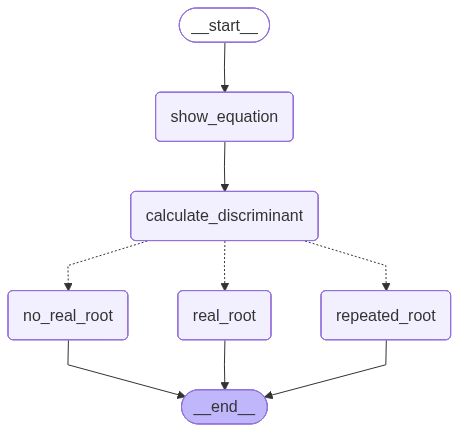

In [49]:
workflow